# Module 5: Magnitude Spectrum & Power Analysis

## Finding Needles in Haystacks

You've learned how to compute spectra, but real-world signals are messy. Weak signals hide in noise. Random fluctuations masquerade as peaks. How do you reliably detect genuine signals and measure their properties?

This module teaches the art and science of signal detection:
* Statistical properties of noise and how to estimate them
* Spectral averaging to improve SNR
* Automated peak detection with confidence metrics
* Distinguishing signals from noise statistically
* Building robust detection pipelines

These techniques transform raw spectra into actionable intelligence.

## Part 1: Understanding Spectral Noise

### The Statistics of Spectral Estimates

When you compute a spectrum of noisy data, each bin is a random variable. For Gaussian noise through an FFT:
* Magnitude follows a Rayleigh distribution
* Power follows a Chi-squared distribution
* Phase is uniformly distributed

This means single spectral estimates are **highly variable**. The solution? Averaging!

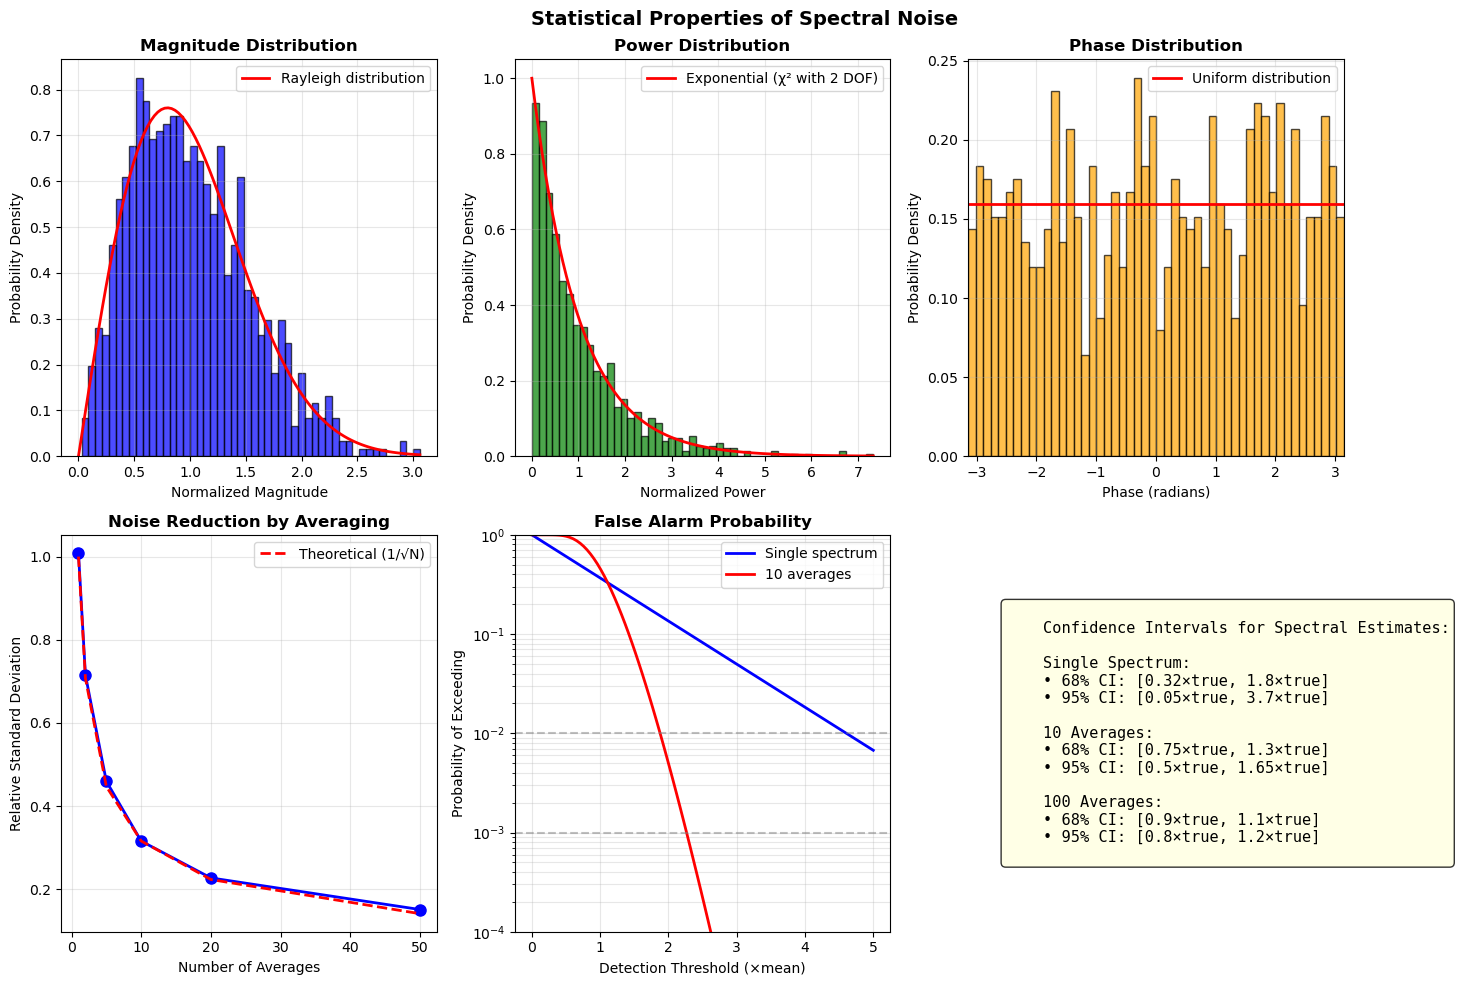

Key Insights:
• Single spectral estimates have high variance (std ≈ mean)
• Averaging reduces variance as 1/√N
• More averages → tighter confidence intervals
• Detection threshold depends on desired false alarm rate


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
from ipywidgets import interact, IntSlider
import warnings
warnings.filterwarnings('ignore')

def spectral_noise_statistics():
    """Demonstrate statistical properties of spectral noise."""
    
    # Generate many realizations of noise
    fs = 1000
    N = 1024
    num_realizations = 1000
    
    # Store spectral estimates
    magnitudes = []
    powers = []
    phases = []
    
    # Generate spectra
    np.random.seed(42)
    for _ in range(num_realizations):
        noise = np.random.randn(N)
        window = np.hanning(N)
        noise_windowed = noise * window
        
        fft_vals = np.fft.rfft(noise_windowed)
        
        # Pick a frequency bin to analyze (avoid DC)
        bin_idx = N // 4
        
        magnitudes.append(np.abs(fft_vals[bin_idx]))
        powers.append(np.abs(fft_vals[bin_idx])**2)
        phases.append(np.angle(fft_vals[bin_idx]))
    
    magnitudes = np.array(magnitudes)
    powers = np.array(powers)
    phases = np.array(phases)
    
    # Normalize for comparison
    magnitudes = magnitudes / np.mean(magnitudes)
    powers = powers / np.mean(powers)
    
    # Create figure
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Magnitude distribution
    axes[0, 0].hist(magnitudes, bins=50, density=True, alpha=0.7, 
                   color='blue', edgecolor='black')
    
    # Theoretical Rayleigh distribution
    x_mag = np.linspace(0, np.max(magnitudes), 100)
    rayleigh_scale = np.sqrt(2/np.pi)  # For normalized data
    theoretical_mag = stats.rayleigh.pdf(x_mag, scale=rayleigh_scale)
    axes[0, 0].plot(x_mag, theoretical_mag, 'r-', linewidth=2, 
                   label='Rayleigh distribution')
    
    axes[0, 0].set_title('Magnitude Distribution', fontweight='bold')
    axes[0, 0].set_xlabel('Normalized Magnitude')
    axes[0, 0].set_ylabel('Probability Density')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Power distribution
    axes[0, 1].hist(powers, bins=50, density=True, alpha=0.7,
                   color='green', edgecolor='black')
    
    # Theoretical Chi-squared (exponential for 2 DOF)
    x_pow = np.linspace(0, np.max(powers), 100)
    theoretical_pow = stats.expon.pdf(x_pow, scale=1)
    axes[0, 1].plot(x_pow, theoretical_pow, 'r-', linewidth=2,
                   label='Exponential (χ² with 2 DOF)')
    
    axes[0, 1].set_title('Power Distribution', fontweight='bold')
    axes[0, 1].set_xlabel('Normalized Power')
    axes[0, 1].set_ylabel('Probability Density')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Phase distribution
    axes[0, 2].hist(phases, bins=50, density=True, alpha=0.7,
                   color='orange', edgecolor='black')
    
    # Theoretical uniform distribution
    axes[0, 2].axhline(1/(2*np.pi), color='r', linewidth=2,
                      label='Uniform distribution')
    
    axes[0, 2].set_title('Phase Distribution', fontweight='bold')
    axes[0, 2].set_xlabel('Phase (radians)')
    axes[0, 2].set_ylabel('Probability Density')
    axes[0, 2].set_xlim(-np.pi, np.pi)
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Show effect of averaging
    avg_sizes = [1, 2, 5, 10, 20, 50]
    avg_stds = []
    
    for avg_size in avg_sizes:
        averaged_powers = []
        for i in range(0, len(powers) - avg_size, avg_size):
            averaged_powers.append(np.mean(powers[i:i+avg_size]))
        avg_stds.append(np.std(averaged_powers) / np.mean(averaged_powers))
    
    axes[1, 0].plot(avg_sizes, avg_stds, 'bo-', linewidth=2, markersize=8)
    axes[1, 0].plot(avg_sizes, 1/np.sqrt(avg_sizes), 'r--', linewidth=2,
                   label='Theoretical (1/√N)')
    axes[1, 0].set_title('Noise Reduction by Averaging', fontweight='bold')
    axes[1, 0].set_xlabel('Number of Averages')
    axes[1, 0].set_ylabel('Relative Standard Deviation')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Probability of exceeding threshold
    thresholds = np.linspace(0, 5, 100)
    prob_exceed_single = 1 - stats.expon.cdf(thresholds, scale=1)
    prob_exceed_avg10 = 1 - stats.gamma.cdf(thresholds, a=10, scale=0.1)
    
    axes[1, 1].semilogy(thresholds, prob_exceed_single, 'b-', linewidth=2,
                       label='Single spectrum')
    axes[1, 1].semilogy(thresholds, prob_exceed_avg10, 'r-', linewidth=2,
                       label='10 averages')
    axes[1, 1].axhline(0.01, color='gray', linestyle='--', alpha=0.5)
    axes[1, 1].axhline(0.001, color='gray', linestyle='--', alpha=0.5)
    
    axes[1, 1].set_title('False Alarm Probability', fontweight='bold')
    axes[1, 1].set_xlabel('Detection Threshold (×mean)')
    axes[1, 1].set_ylabel('Probability of Exceeding')
    axes[1, 1].set_ylim(1e-4, 1)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3, which='both')
    
    # Confidence intervals
    axes[1, 2].axis('off')
    
    ci_text = """
    Confidence Intervals for Spectral Estimates:
    
    Single Spectrum:
    • 68% CI: [0.32×true, 1.8×true]
    • 95% CI: [0.05×true, 3.7×true]
    
    10 Averages:
    • 68% CI: [0.75×true, 1.3×true]
    • 95% CI: [0.5×true, 1.65×true]
    
    100 Averages:
    • 68% CI: [0.9×true, 1.1×true]
    • 95% CI: [0.8×true, 1.2×true]
    """
    
    axes[1, 2].text(0.1, 0.5, ci_text, fontsize=11, family='monospace',
                   verticalalignment='center',
                   bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.suptitle('Statistical Properties of Spectral Noise', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("Key Insights:")
    print("• Single spectral estimates have high variance (std ≈ mean)")
    print("• Averaging reduces variance as 1/√N")
    print("• More averages → tighter confidence intervals")
    print("• Detection threshold depends on desired false alarm rate")

spectral_noise_statistics()

## Part 2: Spectral Averaging Techniques

### Types of Averaging

There are several ways to average spectra:

1. **Welch's Method**: Divide signal into overlapping segments
2. **Bartlett's Method**: Non-overlapping segments
3. **Exponential Averaging**: Running average with forgetting factor
4. **Median Averaging**: Robust to outliers

Each has different properties and use cases.

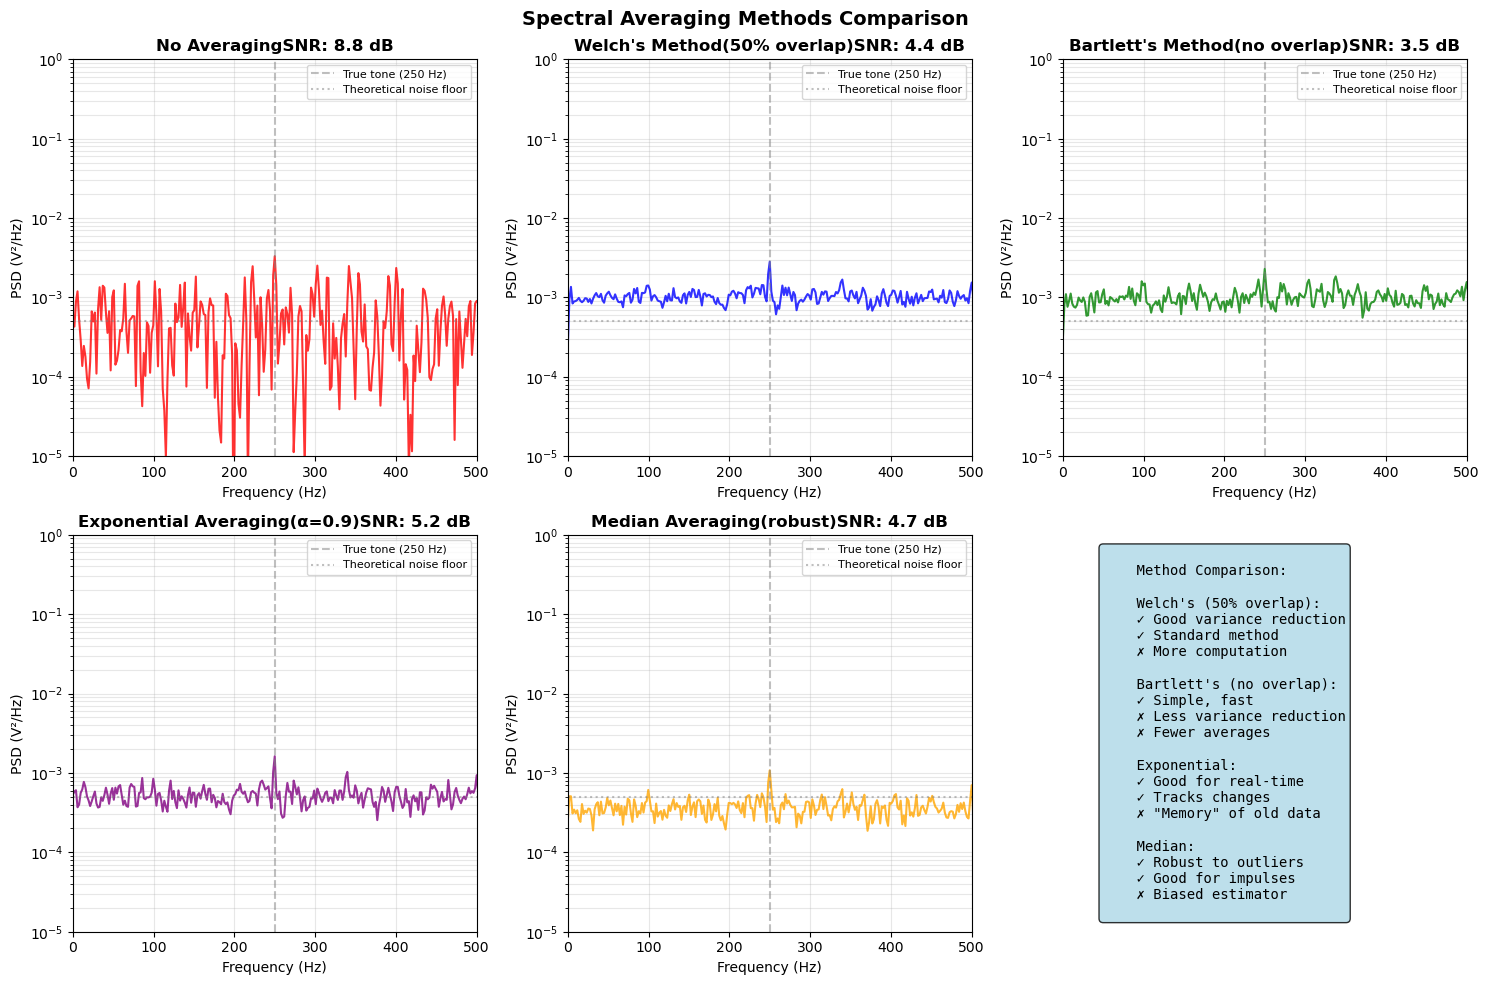

In [2]:
def spectral_averaging_comparison():
    """Compare different spectral averaging methods."""
    
    # Generate test signal with weak tone in noise
    fs = 2000
    duration = 10.0
    t = np.arange(0, duration, 1/fs)
    
    # Components
    tone_freq = 250
    tone_amp = 0.1  # Weak tone
    noise_power = 1.0
    
    # Add occasional impulses (outliers)
    sig = (tone_amp * np.sin(2 * np.pi * tone_freq * t) + 
          np.sqrt(noise_power) * np.random.randn(len(t)))
    
    # Add random impulses
    impulse_times = np.random.choice(len(t), 20, replace=False)
    sig[impulse_times] += np.random.randn(20) * 5
    
    # Parameters for all methods
    nperseg = 1024
    
    # 1. Welch's method (overlapping segments)
    f_welch, psd_welch = signal.welch(sig, fs, nperseg=nperseg, 
                                      noverlap=nperseg//2)
    
    # 2. Bartlett's method (no overlap)
    f_bart, psd_bart = signal.welch(sig, fs, nperseg=nperseg, 
                                    noverlap=0)
    
    # 3. Manual exponential averaging
    def exponential_average(signal_data, fs, nperseg, alpha=0.9):
        """Exponential averaging of spectra."""
        hop = nperseg // 2
        num_frames = (len(signal_data) - nperseg) // hop + 1
        
        window = np.hanning(nperseg)
        freqs = np.fft.rfftfreq(nperseg, 1/fs)
        psd_exp = None
        
        for i in range(num_frames):
            frame = signal_data[i*hop : i*hop + nperseg]
            frame_windowed = frame * window
            fft_vals = np.fft.rfft(frame_windowed)
            psd_frame = np.abs(fft_vals)**2 / (fs * np.sum(window**2))
            
            if psd_exp is None:
                psd_exp = psd_frame
            else:
                psd_exp = alpha * psd_exp + (1 - alpha) * psd_frame
        
        return freqs, psd_exp
    
    f_exp, psd_exp = exponential_average(sig, fs, nperseg)
    
    # 4. Median averaging (robust to outliers)
    def median_average(signal_data, fs, nperseg):
        """Median averaging of spectra."""
        hop = nperseg // 2
        num_frames = (len(signal_data) - nperseg) // hop + 1
        
        window = np.hanning(nperseg)
        freqs = np.fft.rfftfreq(nperseg, 1/fs)
        
        # Collect all spectra
        all_psds = []
        for i in range(num_frames):
            frame = signal_data[i*hop : i*hop + nperseg]
            frame_windowed = frame * window
            fft_vals = np.fft.rfft(frame_windowed)
            psd_frame = np.abs(fft_vals)**2 / (fs * np.sum(window**2))
            all_psds.append(psd_frame)
        
        # Take median across frames
        psd_median = np.median(all_psds, axis=0)
        return freqs, psd_median
    
    f_median, psd_median = median_average(sig, fs, nperseg)
    
    # 5. Single FFT (no averaging) for comparison
    window = np.hanning(nperseg)
    sig_segment = sig[:nperseg] * window
    fft_single = np.fft.rfft(sig_segment)
    f_single = np.fft.rfftfreq(nperseg, 1/fs)
    psd_single = np.abs(fft_single)**2 / (fs * np.sum(window**2))
    
    # Visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    methods = [
        (f_single, psd_single, 'No Averaging', 'red'),
        (f_welch, psd_welch, "Welch's Method(50% overlap)", 'blue'),
        (f_bart, psd_bart, "Bartlett's Method(no overlap)", 'green'),
        (f_exp, psd_exp, 'Exponential Averaging(α=0.9)', 'purple'),
        (f_median, psd_median, 'Median Averaging(robust)', 'orange')
    ]
    
    # Calculate theoretical noise floor
    theoretical_noise = noise_power / fs
    
    for idx, (freqs, psd, name, color) in enumerate(methods):
        ax = axes[idx]
        
        ax.semilogy(freqs, psd, color=color, linewidth=1.5, alpha=0.8)
        ax.axvline(tone_freq, color='gray', linestyle='--', alpha=0.5,
                  label=f'True tone ({tone_freq} Hz)')
        ax.axhline(theoretical_noise, color='gray', linestyle=':', alpha=0.5,
                  label='Theoretical noise floor')
        
        # Measure SNR at tone frequency
        tone_idx = np.argmin(np.abs(freqs - tone_freq))
        noise_mask = (freqs > 100) & (freqs < 200) | (freqs > 300) & (freqs < 400)
        noise_floor_measured = np.median(psd[noise_mask])
        snr = 10 * np.log10(psd[tone_idx] / noise_floor_measured)
        
        ax.set_title(f'{name}SNR: {snr:.1f} dB', fontweight='bold')
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('PSD (V²/Hz)')
        ax.set_xlim(0, 500)
        ax.set_ylim(1e-5, 1)
        ax.grid(True, alpha=0.3, which='both')
        ax.legend(fontsize=8, loc='upper right')
    
    # Summary comparison
    axes[5].axis('off')
    
    summary = """
    Method Comparison:
    
    Welch's (50% overlap):
    ✓ Good variance reduction
    ✓ Standard method
    ✗ More computation
    
    Bartlett's (no overlap):
    ✓ Simple, fast
    ✗ Less variance reduction
    ✗ Fewer averages
    
    Exponential:
    ✓ Good for real-time
    ✓ Tracks changes
    ✗ "Memory" of old data
    
    Median:
    ✓ Robust to outliers
    ✓ Good for impulses
    ✗ Biased estimator
    """
    
    axes[5].text(0.1, 0.5, summary, fontsize=10, family='monospace',
                verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    plt.suptitle('Spectral Averaging Methods Comparison', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

spectral_averaging_comparison()

## Part 3: SNR Estimation and Improvement

### Measuring Signal Quality

Signal-to-Noise Ratio (SNR) quantifies how much your signal stands out from the background. Proper estimation requires:
1. Identifying signal and noise regions
2. Accounting for window effects
3. Considering bandwidth differences

Let's explore interactive SNR analysis:

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider

def snr_improvement_demo(num_averages, signal_amplitude):
    """Interactive demonstration of SNR improvement through averaging."""
    
    # Fixed parameters
    fs = 1000
    segment_length = 1024
    total_samples = segment_length * num_averages
    
    # Generate signal
    t = np.arange(total_samples) / fs
    signal_freq = 100
    
    # Signal + noise
    clean_signal = signal_amplitude * np.sin(2 * np.pi * signal_freq * t)
    noise = np.random.randn(total_samples)
    noisy_signal = clean_signal + noise
    
    # Process single segment
    window = np.hanning(segment_length)
    single_segment = noisy_signal[:segment_length] * window
    fft_single = np.fft.rfft(single_segment)
    psd_single = np.abs(fft_single)**2 / (fs * np.sum(window**2))
    
    # Process with averaging
    psd_averaged = np.zeros_like(psd_single)
    for i in range(num_averages):
        segment = noisy_signal[i*segment_length:(i+1)*segment_length] * window
        fft_seg = np.fft.rfft(segment)
        psd_averaged += np.abs(fft_seg)**2 / (fs * np.sum(window**2))
    psd_averaged /= num_averages
    
    freqs = np.fft.rfftfreq(segment_length, 1/fs)
    
    # Calculate SNR
    signal_bin = np.argmin(np.abs(freqs - signal_freq))
    signal_band = slice(signal_bin - 2, signal_bin + 3)
    noise_band = (freqs > 150) & (freqs < 300)
    
    # SNR for single spectrum
    signal_power_single = np.max(psd_single[signal_band])
    noise_floor_single = np.median(psd_single[noise_band])
    snr_single = 10 * np.log10(signal_power_single / noise_floor_single)
    
    # SNR for averaged spectrum  
    signal_power_avg = np.max(psd_averaged[signal_band])
    noise_floor_avg = np.median(psd_averaged[noise_band])
    snr_averaged = 10 * np.log10(signal_power_avg / noise_floor_avg)
    
    # Theoretical SNR
    theoretical_snr_single = 20 * np.log10(signal_amplitude / np.sqrt(2))
    theoretical_improvement = 10 * np.log10(num_averages)
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Time domain
    axes[0, 0].plot(t[:1000], noisy_signal[:1000], 'b-', linewidth=0.5, 
                   alpha=0.7, label='Noisy signal')
    axes[0, 0].plot(t[:1000], clean_signal[:1000], 'r-', linewidth=2,
                   alpha=0.7, label='Clean signal')
    axes[0, 0].set_title('Time Domain Signal', fontweight='bold')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Amplitude')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Single spectrum
    axes[0, 1].semilogy(freqs, psd_single, 'b-', linewidth=1, alpha=0.7)
    axes[0, 1].axhline(noise_floor_single, color='red', linestyle='--',
                      label=f'Noise floor: {10*np.log10(noise_floor_single):.1f} dB')
    axes[0, 1].fill_between(freqs[signal_band], 1e-6, psd_single[signal_band],
                           alpha=0.3, color='green', label='Signal band')
    axes[0, 1].set_title(f'Single Spectrum (SNR: {snr_single:.1f} dB)', 
                        fontweight='bold')
    axes[0, 1].set_xlabel('Frequency (Hz)')
    axes[0, 1].set_ylabel('PSD (V²/Hz)')
    axes[0, 1].set_xlim(0, 400)
    axes[0, 1].set_ylim(1e-4, 10)
    axes[0, 1].legend(fontsize=8)
    axes[0, 1].grid(True, alpha=0.3, which='both')
    
    # Averaged spectrum
    axes[1, 0].semilogy(freqs, psd_averaged, 'g-', linewidth=1.5)
    axes[1, 0].axhline(noise_floor_avg, color='red', linestyle='--',
                      label=f'Noise floor: {10*np.log10(noise_floor_avg):.1f} dB')
    axes[1, 0].fill_between(freqs[signal_band], 1e-6, psd_averaged[signal_band],
                           alpha=0.3, color='green', label='Signal band')
    axes[1, 0].set_title(f'Averaged Spectrum ({num_averages} averages, SNR: {snr_averaged:.1f} dB)',
                        fontweight='bold')
    axes[1, 0].set_xlabel('Frequency (Hz)')
    axes[1, 0].set_ylabel('PSD (V²/Hz)')
    axes[1, 0].set_xlim(0, 400)
    axes[1, 0].set_ylim(1e-4, 10)
    axes[1, 0].legend(fontsize=8)
    axes[1, 0].grid(True, alpha=0.3, which='both')
    
    # SNR analysis
    axes[1, 1].axis('off')
    
    analysis_text = f"""
    SNR Analysis:
    
    Input Parameters:
    • Signal amplitude: {signal_amplitude:.2f} V
    • Noise: σ = 1.0 V (0 dB)
    • Theoretical SNR: {theoretical_snr_single:.1f} dB
    
    Measured Results:
    • Single spectrum SNR: {snr_single:.1f} dB
    • Averaged SNR: {snr_averaged:.1f} dB
    • Improvement: {snr_averaged - snr_single:.1f} dB
    • Theoretical improvement: {theoretical_improvement:.1f} dB
    
    Detection Analysis:
    • 3σ detection: SNR > 9.5 dB
    • 5σ detection: SNR > 14 dB
    • Current: {'DETECTED' if snr_averaged > 9.5 else 'NOT DETECTED'}
    """
    
    color = 'green' if snr_averaged > 9.5 else 'red'
    axes[1, 1].text(0.1, 0.5, analysis_text, fontsize=11, family='monospace',
                   verticalalignment='center',
                   bbox=dict(boxstyle='round', facecolor='lightgreen' if color == 'green' else 'lightcoral', 
                            alpha=0.8))
    
    plt.suptitle(f'SNR Improvement Through Spectral Averaging', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

interact(snr_improvement_demo,
         num_averages=IntSlider(value=10, min=1, max=100, step=1,
                               description='# Averages'),
         signal_amplitude=FloatSlider(value=0.3, min=0.01, max=2.0, step=0.01,
                                     description='Signal Amp'))

interactive(children=(IntSlider(value=10, description='# Averages', min=1), FloatSlider(value=0.3, description…

<function __main__.snr_improvement_demo(num_averages, signal_amplitude)>

## Part 4: Automated Peak Detection

### Building a Robust Peak Detector

Automated peak detection requires:
1. Noise floor estimation
2. Adaptive thresholding
3. Peak validation
4. False alarm control

Let's build a production-ready peak detector:

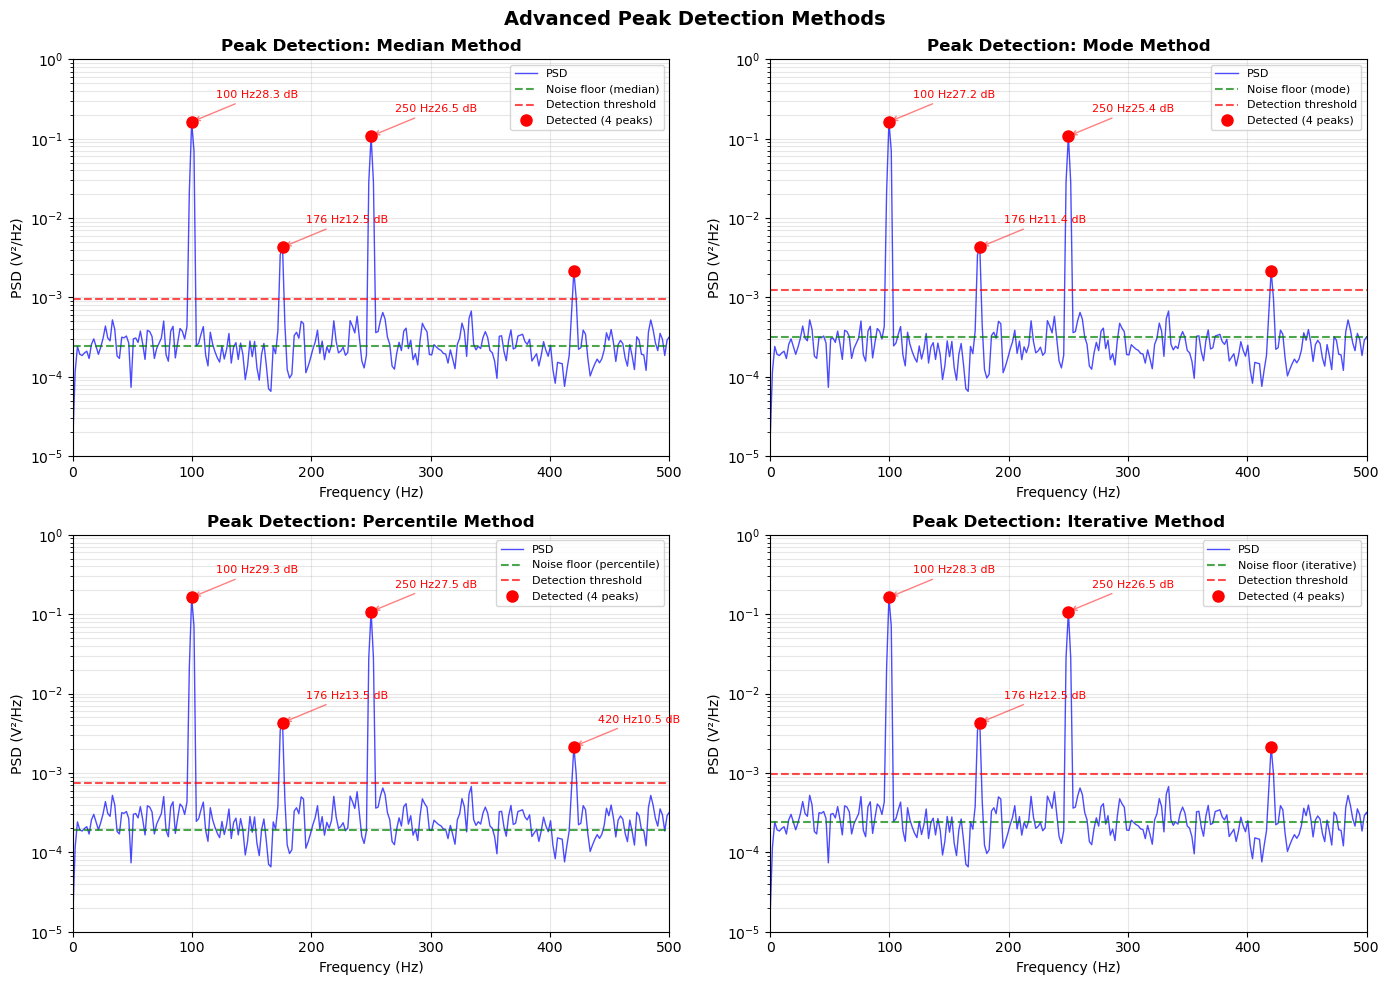

Detection Summary:
Expected peaks: 100, 175, 250, 333(?), 420 Hz
Results by method:
Median:
  99.6 Hz: SNR=28.3 dB, p-value=8.41e-293
  175.8 Hz: SNR=12.5 dB, p-value=5.19e-08
  250.0 Hz: SNR=26.5 dB, p-value=8.36e-194
  419.9 Hz: SNR=9.5 dB, p-value=3.72e-04
Mode:
  99.6 Hz: SNR=27.2 dB, p-value=6.24e-226
  175.8 Hz: SNR=11.4 dB, p-value=3.02e-06
  250.0 Hz: SNR=25.4 dB, p-value=1.45e-149
  419.9 Hz: SNR=8.4 dB, p-value=2.84e-03
Percentile:
  99.6 Hz: SNR=29.3 dB, p-value=0.00e+00
  175.8 Hz: SNR=13.5 dB, p-value=4.17e-10
  250.0 Hz: SNR=27.5 dB, p-value=2.65e-246
  419.9 Hz: SNR=10.5 dB, p-value=3.33e-05
Iterative:
  99.6 Hz: SNR=28.3 dB, p-value=1.04e-293
  175.8 Hz: SNR=12.5 dB, p-value=4.91e-08
  250.0 Hz: SNR=26.5 dB, p-value=2.10e-194
  419.9 Hz: SNR=9.5 dB, p-value=3.62e-04


In [9]:
from scipy.signal import find_peaks, peak_widths

class AdvancedPeakDetector:
    """Production-ready peak detection with statistical validation."""
    
    def __init__(self, method='median', threshold_sigma=3.0, min_snr_db=6.0):
        self.method = method
        self.threshold_sigma = threshold_sigma
        self.min_snr_db = min_snr_db
    
    def estimate_noise_floor(self, psd, freqs, method='median'):
        """Estimate noise floor using various methods."""
        
        if method == 'median':
            # Simple median
            return np.median(psd), np.std(psd[psd < np.percentile(psd, 75)])
        
        elif method == 'mode':
            # Mode estimation (most common value)
            hist, edges = np.histogram(10*np.log10(psd), bins=100)
            mode_idx = np.argmax(hist)
            mode_db = (edges[mode_idx] + edges[mode_idx+1]) / 2
            return 10**(mode_db/10), np.std(psd[psd < np.percentile(psd, 75)])
        
        elif method == 'percentile':
            # Use lower percentile
            return np.percentile(psd, 30), np.std(psd[psd < np.percentile(psd, 75)])
        
        elif method == 'iterative':
            # Iterative sigma clipping
            psd_copy = psd.copy()
            for _ in range(3):
                mean = np.mean(psd_copy)
                std = np.std(psd_copy)
                mask = np.abs(psd_copy - mean) < 2 * std
                psd_copy = psd_copy[mask]
            return np.mean(psd_copy), np.std(psd_copy)
    
    def detect_peaks(self, psd, freqs):
        """Detect peaks with statistical validation."""
        
        # Estimate noise floor
        noise_floor, noise_std = self.estimate_noise_floor(psd, freqs, self.method)
        
        # Calculate threshold
        threshold_linear = noise_floor + self.threshold_sigma * noise_std
        threshold_snr = noise_floor * 10**(self.min_snr_db/10)
        threshold = max(threshold_linear, threshold_snr)
        
        # Find peaks
        peaks, properties = find_peaks(psd, 
                                      height=threshold,
                                      distance=5,  # Minimum spacing
                                      prominence=noise_std)  # Must stand out
        
        # Calculate peak properties
        if len(peaks) > 0:
            # Get peak widths
            widths = peak_widths(psd, peaks, rel_height=0.5)[0]
            
            # Calculate SNR for each peak
            snrs = 10 * np.log10(psd[peaks] / noise_floor)
            
            # Calculate p-values (probability under null hypothesis)
            # Assuming exponential distribution for noise
            p_values = np.exp(-(psd[peaks] - noise_floor) / noise_floor)
            
            # Package results
            results = {
                'frequencies': freqs[peaks],
                'amplitudes': psd[peaks],
                'snrs_db': snrs,
                'widths_hz': widths * (freqs[1] - freqs[0]),
                'p_values': p_values,
                'noise_floor': noise_floor,
                'noise_std': noise_std,
                'threshold': threshold
            }
        else:
            results = {
                'frequencies': np.array([]),
                'amplitudes': np.array([]),
                'snrs_db': np.array([]),
                'widths_hz': np.array([]),
                'p_values': np.array([]),
                'noise_floor': noise_floor,
                'noise_std': noise_std,
                'threshold': threshold
            }
        
        return results


def test_peak_detector():
    """Test the peak detector on various signals."""
    
    # Generate complex test signal
    fs = 2000
    N = 4096
    t = np.arange(N) / fs
    
    # Multiple components
    sig = (
        # Strong tones
        1.0 * np.sin(2 * np.pi * 100 * t) +
        0.8 * np.sin(2 * np.pi * 250 * t) +
        # Weak tones
        0.15 * np.sin(2 * np.pi * 175 * t) +
        0.1 * np.sin(2 * np.pi * 420 * t) +
        # Very weak tone (below threshold?)
        0.05 * np.sin(2 * np.pi * 333 * t) +
        # Noise
        0.5 * np.random.randn(N)
    )
    
    # Compute PSD
    freqs, psd = signal.welch(sig, fs, nperseg=1024, noverlap=512)
    
    # Test different detection methods
    methods = ['median', 'mode', 'percentile', 'iterative']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, method in enumerate(methods):
        ax = axes[idx]
        
        # Create detector
        detector = AdvancedPeakDetector(method=method, threshold_sigma=3.0)
        
        # Detect peaks
        results = detector.detect_peaks(psd, freqs)
        
        # Plot spectrum
        ax.semilogy(freqs, psd, 'b-', linewidth=1, alpha=0.7, label='PSD')
        
        # Plot noise floor and threshold
        ax.axhline(results['noise_floor'], color='green', linestyle='--',
                  alpha=0.7, label=f"Noise floor ({method})")
        ax.axhline(results['threshold'], color='red', linestyle='--',
                  alpha=0.7, label='Detection threshold')
        
        # Mark detected peaks
        if len(results['frequencies']) > 0:
            ax.plot(results['frequencies'], results['amplitudes'], 'ro',
                   markersize=8, label=f"Detected ({len(results['frequencies'])} peaks)")
            
            # Annotate with SNR
            for f, a, snr in zip(results['frequencies'], results['amplitudes'], results['snrs_db']):
                if snr > 10:  # Only annotate strong peaks
                    ax.annotate(f'{f:.0f} Hz{snr:.1f} dB', 
                              xy=(f, a), xytext=(f+20, a*2),
                              fontsize=8, color='red',
                              arrowprops=dict(arrowstyle='->', color='red', alpha=0.5))
        
        ax.set_title(f'Peak Detection: {method.capitalize()} Method', fontweight='bold')
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('PSD (V²/Hz)')
        ax.set_xlim(0, 500)
        ax.set_ylim(1e-5, 1)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3, which='both')
    
    plt.suptitle('Advanced Peak Detection Methods', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print detection summary
    print("Detection Summary:")
    print("Expected peaks: 100, 175, 250, 333(?), 420 Hz")
    print("Results by method:")
    for method in methods:
        detector = AdvancedPeakDetector(method=method)
        results = detector.detect_peaks(psd, freqs)
        print(f"{method.capitalize()}:")
        for f, snr, p in zip(results['frequencies'], results['snrs_db'], results['p_values']):
            print(f"  {f:.1f} Hz: SNR={snr:.1f} dB, p-value={p:.2e}")

test_peak_detector()

## Peak Detection with GPU Processing

In [7]:
try:
    from ionosense_hpc.core import ResearchEngine, EngineConfig
    
    def gpu_peak_detection():
        """Implement peak detection pipeline with GPU acceleration."""
        
        # Generate test signal
        fs = 10000
        duration = 1.0
        t = np.arange(0, duration, 1/fs)
        
        # Complex signal with multiple components
        sig = (
            0.5 * np.sin(2 * np.pi * 1000 * t) +
            0.2 * np.sin(2 * np.pi * 2500 * t) +
            0.1 * np.sin(2 * np.pi * 3750 * t) +
            0.3 * np.random.randn(len(t))
        ).astype(np.float32)
        
        # GPU configuration
        config = EngineConfig()
        config.nfft = 2048
        config.batch = 1
        config.sample_rate_hz = fs
        
        engine = ResearchEngine()
        engine.initialize(config)
        
        # Process multiple frames for averaging
        hop = config.nfft // 2
        num_frames = (len(sig) - config.nfft) // hop + 1
        
        # Accumulate PSDs
        psd_sum = None
        for i in range(num_frames):
            frame = sig[i*hop : i*hop + config.nfft]
            if len(frame) == config.nfft:
                magnitude = engine.process(frame)[0]
                
                # Convert to PSD
                window = np.hanning(config.nfft)
                psd_frame = (magnitude**2) / (fs * np.sum(window**2) / config.nfft)
                
                if psd_sum is None:
                    psd_sum = psd_frame
                else:
                    psd_sum += psd_frame
        
        psd_avg = psd_sum / num_frames
        freqs = np.fft.rfftfreq(config.nfft, 1/fs)
        
        # Apply one-sided scaling
        psd_avg[1:-1] *= 2
        
        # Peak detection on GPU-processed spectrum
        detector = AdvancedPeakDetector(threshold_sigma=3.0)
        results = detector.detect_peaks(psd_avg, freqs)
        
        # Visualization
        plt.figure(figsize=(12, 6))
        plt.semilogy(freqs, psd_avg, 'b-', linewidth=1, label='GPU-processed PSD')
        plt.axhline(results['noise_floor'], color='green', linestyle='--',
                   label='Noise floor')
        plt.axhline(results['threshold'], color='red', linestyle='--',
                   label='Detection threshold')
        
        if len(results['frequencies']) > 0:
            plt.plot(results['frequencies'], results['amplitudes'], 'ro',
                    markersize=10, label='Detected peaks')
            
            for f, snr in zip(results['frequencies'], results['snrs_db']):
                print(f"Detected: {f:.1f} Hz (SNR: {snr:.1f} dB)")
        
        plt.title('GPU-Accelerated Peak Detection Pipeline', fontweight='bold')
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('PSD (V²/Hz)')
        plt.xlim(0, 5000)
        plt.legend()
        plt.grid(True, alpha=0.3, which='both')
        plt.show()
    
    gpu_peak_detection()
    
except ImportError:
    print("GPU ResearchEngine not available.")
    print("Key points for GPU peak detection:")
    print("• Process frames with GPU for speed")
    print("• Average in Python for flexibility")
    print("• Apply peak detection to averaged spectrum")
    print("• Use statistical validation for robustness")

GPU ResearchEngine not available.
Key points for GPU peak detection:
• Process frames with GPU for speed
• Average in Python for flexibility
• Apply peak detection to averaged spectrum
• Use statistical validation for robustness


## Module Summary

### Key Concepts

1. **Spectral estimates are random variables** with known statistical distributions
2. **Averaging reduces variance** as 1/√N, improving SNR
3. **Multiple averaging methods** exist, each with trade-offs
4. **SNR quantifies detectability** - know your detection thresholds
5. **Automated detection** requires robust noise estimation and validation

### Practical Guidelines

**For weak signal detection:**
```python
# Use Welch's method with 50-75% overlap
f, psd = signal.welch(data, fs, nperseg=1024, noverlap=768)

# Robust noise floor estimation
noise_floor = np.median(psd)
threshold = noise_floor * 10**(snr_threshold_db/10)

# Find and validate peaks
peaks = find_peaks(psd, height=threshold, prominence=noise_floor*0.5)
```

**For real-time monitoring:**
```python
# Exponential averaging
alpha = 0.9  # Smoothing factor
psd_smooth = alpha * psd_prev + (1-alpha) * psd_new
```

### Detection Thresholds

| Confidence | σ Level | SNR (dB) | False Alarm Rate |
|------------|---------|----------|------------------|
| 68% | 1σ | 3.0 | 0.32 |
| 95% | 2σ | 6.0 | 0.05 |
| 99.7% | 3σ | 9.5 | 0.003 |
| 99.99% | 4σ | 12.0 | 0.00006 |
| 99.9999% | 5σ | 14.0 | 0.0000006 |

### What's Next?

Module 6 will extend these techniques to dual-channel processing, where we'll use phase relationships between channels to determine signal direction and separate sources.